In [1]:
import pandas as pd, ast, matplotlib.pyplot as plt
import json, re
from pathlib import Path
from difflib import ndiff

CSV_BASELINE_PATTERN = "csv_log/P{pid}_baseline.csv"
CSV_OOPT_PATTERN     = "csv_log/P{pid}_OOPT.csv"
JSONL_OOPT_PATTERN   = "jsonl/P{pid}.jsonl"
TARGET_EVENT = "api.generate_text_to_graph.succeeded"

PAIR_RE = re.compile(
    r'(?:Previous description:\s*"(?P<prev>.*?)")?\s*New description:\s*"(?P<new>.*?)"',
    re.S
)

def count_changed_words(old, new):
    if old is None or not new:
        return 0
    diff = [d for d in ndiff(str(old).split(), str(new).split()) if d[0] in "+-"]
    return len(diff)

def process_baseline(path, pid):
    df = pd.read_csv(path)
    df["details"] = df["details"].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else {})
    df["ts"] = pd.to_datetime(df["timestamp"], format="%H:%M:%S", errors="coerce")

    edits = df[df["event"]=="baselineboard.node.edit"].copy().sort_values("ts")
    recs, prev_text, prev_time = [], {}, {}

    for _, row in edits.iterrows():
        det = row["details"]; node = det.get("nodeId"); new_text = det.get("newLabel"); t = row["ts"]
        if node in prev_text and pd.notna(t) and pd.notna(prev_time.get(node)):
            old = prev_text[node] if prev_text[node] is not None else ""
            new = new_text if new_text is not None else ""
            diff = sum(1 for _ in (set(str(old).split()) ^ set(str(new).split())))
            wc = diff if diff > 0 else 1
            dur = (t - prev_time[node]).total_seconds()
            recs.append([pid, node, dur, wc, dur/wc if wc else None])
        prev_text[node] = new_text
        prev_time[node] = t

    return pd.DataFrame(recs, columns="pid nodeId duration_sec words_changed sec_per_word".split())

def process_oopt_node(path, pid):
    df = pd.read_csv(path)
    df["details"] = df["details"].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else {})
    df["ts"] = pd.to_datetime(df["timestamp"], format="%H:%M:%S", errors="coerce")

    edits = df[df["event"]=="object_node.edit.saved"].copy().sort_values("ts")
    recs = []
    for i, row in edits.iterrows():
        node_id = row["details"].get("nodeId"); t_curr = row["ts"]
        dur = (t_curr - df.loc[i-1, "ts"]).total_seconds() if (i-1 in df.index and pd.notna(t_curr) and pd.notna(df.loc[i-1,"ts"])) else None
        recs.append([pid, node_id, dur, 1, dur])
    return pd.DataFrame(recs, columns="pid nodeId duration_sec words_changed sec_per_word".split())

# ★ 수정된 부분: Prev가 없으면 None을 그대로 유지 → duration과 먼저 정렬 → 이후 None 제외
def process_oopt_text_jsonl(jsonl_path, csv_path, pid):
    if not Path(jsonl_path).exists() or not Path(csv_path).exists():
        print("Path not exist")
        return pd.DataFrame(columns="pid nodeId duration_sec words_changed sec_per_word".split())

    # 1) JSONL에서 prev/new 추출 (prev 미존재 시 None을 그대로 유지)
    pairs = []
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except json.JSONDecodeError:
                continue
            raw_input = obj.get("input", "")
            if not raw_input:
                continue
            # m = PAIR_RE.search(raw_input)
            m = re.search(
                r'Previous\s*Description\s*:\s*"(?P<prev>(?:[^"\\]|\\.)*)"', 
                raw_input, 
                re.I
            )
            # return m.group("prev") if m else None
            prev_desc = m.group("prev") if m and m.group("prev") else None
            m = re.search(
                r'New\s*Description\s*:\s*"(?P<new>(?:[^"\\]|\\.)*)"', 
                raw_input, 
                re.I
            )
            new_desc = m.group("new") if m else None
            # if not m:
            #     continue
            # prev가 None이더라도 무조건 추가 (정렬 유지 목적)
            pairs.append((prev_desc, new_desc))
    # print(pairs)
    
    if not pairs:
        print("No Pairs")
        return pd.DataFrame(columns="pid nodeId duration_sec words_changed sec_per_word".split())

    # 2) CSV에서 duration 시퀀스 추출 (타겟 이벤트마다 직전 이벤트와 차이)
    df = pd.read_csv(csv_path)
    df["ts"] = pd.to_datetime(df["timestamp"], format="%H:%M:%S", errors="coerce")
    durations = []
    for idx, row in df.iterrows():
        if row.get("event") == TARGET_EVENT:
            prev_idx = idx - 1
            if prev_idx in df.index and pd.notna(df.loc[prev_idx,"ts"]) and pd.notna(row["ts"]):
                durations.append((row["ts"] - df.loc[prev_idx,"ts"]).total_seconds())

    if not durations:
        print("No duration")
        return pd.DataFrame(columns="pid nodeId duration_sec words_changed sec_per_word".split())

    # 3) 길이를 min으로 맞춰 1:1 매칭 (Prev None 포함 상태로 먼저 duration 연결)
    if(len(pairs) != len(durations)): print("Length not match! Min length will be used.")
    n = min(len(pairs), len(durations))
    pairs = pairs[:n]; durations = durations[:n]

    df_raw = pd.DataFrame({
        "pid": [pid]*n,
        "previous_description": [p[0] for p in pairs],
        "new_description": [p[1] for p in pairs],
        "duration_sec": durations,
        "nodeId": [f"textedit_{i}" for i in range(n)]
    })

    # 4) 이후 None prev를 제외하고 계산
    df_valid = df_raw[df_raw["previous_description"].notna()].copy()
    if df_valid.empty:
        return pd.DataFrame(columns="pid nodeId duration_sec words_changed sec_per_word".split())

    df_valid["words_changed"] = df_valid.apply(
        lambda r: count_changed_words(r["previous_description"], r["new_description"]),
        axis=1
    )
    df_valid = df_valid[df_valid["words_changed"] > 0].copy()

    if df_valid.empty:
        return pd.DataFrame(columns="pid nodeId duration_sec words_changed sec_per_word".split())

    df_valid["sec_per_word"] = df_valid["duration_sec"] / df_valid["words_changed"]
    return df_valid[["pid","nodeId","duration_sec","words_changed","sec_per_word"]]

# -------------------------
# 모든 참가자 합치기
# -------------------------
baseline_all, oopt_node_all, oopt_text_all = [], [], []
for i in range(1, 13):
    pid = f"P{i}"
    bpath = CSV_BASELINE_PATTERN.format(pid=i)
    opath = CSV_OOPT_PATTERN.format(pid=i)
    jpath = JSONL_OOPT_PATTERN.format(pid=i)

    if Path(bpath).exists():
        baseline_all.append(process_baseline(bpath, pid))
    if Path(opath).exists():
        oopt_node_all.append(process_oopt_node(opath, pid))
    if Path(jpath).exists() and Path(opath).exists():
        oopt_text_all.append(process_oopt_text_jsonl(jpath, opath, pid))

baseline_all = pd.concat(baseline_all, ignore_index=True) if baseline_all else pd.DataFrame(columns="pid nodeId duration_sec words_changed sec_per_word".split())
oopt_node_all = pd.concat(oopt_node_all, ignore_index=True) if oopt_node_all else pd.DataFrame(columns="pid nodeId duration_sec words_changed sec_per_word".split())
oopt_text_all = pd.concat(oopt_text_all, ignore_index=True) if oopt_text_all else pd.DataFrame(columns="pid nodeId duration_sec words_changed sec_per_word".split())

oopt_all = pd.concat([oopt_node_all, oopt_text_all], ignore_index=True)

baseline_all["system"] = "Baseline"
oopt_all["system"] = "OOPT"
final = pd.concat([baseline_all, oopt_all], ignore_index=True)

/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_47397/3779559347.py:162: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  baseline_all = pd.concat(baseline_all, ignore_index=True) if baseline_all else pd.DataFrame(columns="pid nodeId duration_sec words_changed sec_per_word".split())
/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_47397/3779559347.py:164: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  oopt_text_all = pd.concat(oopt_text_all, ignore_index=True) if oopt_text_all e

          count      mean       std       min       25%       50%       75%  \
system                                                                        
Baseline   47.0  0.043641  0.046847  0.003175  0.013776  0.022346  0.073377   
OOPT      190.0  0.335101  0.783227  0.007692  0.051389  0.111111  0.250000   

               max  
system              
Baseline  0.222222  
OOPT      8.000000  

[Counts]
Final rows (after removing zeros): 237

ENHANCED STATISTICS - WORDS PER SECOND

Baseline:
  Count: 47
  Mean: 0.0436
  Median: 0.0223
  Std: 0.0468
  Min: 0.0032
  Max: 0.2222
  Q1: 0.0138
  Q3: 0.0734
  IQR: 0.0596

OOPT:
  Count: 190
  Mean: 0.3351
  Median: 0.1111
  Std: 0.7832
  Min: 0.0077
  Max: 8.0000
  Q1: 0.0514
  Q3: 0.2500
  IQR: 0.1986


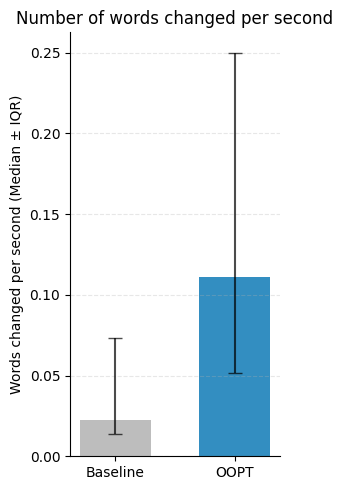

In [2]:
# -------------------------
# Styled Bar Chart (맞춤형) - Modified for words_per_sec
# -------------------------
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# 팔레트 (기존과 동일)
COLOR = {"Baseline": "#BDBDBD",  # 회색
         "OOPT": "#0072B2"}      # 파랑

# -------------------------
# Data preprocessing: Convert sec_per_word to words_per_sec and remove zeros
# -------------------------
# Assuming 'final' dataframe exists with 'sec_per_word' column
# Convert sec_per_word to words_per_sec (reciprocal)
final['words_per_sec'] = 1 / final['sec_per_word']

# Remove rows where sec_per_word was 0 (which would make words_per_sec infinite)
# Also remove any infinite or NaN values
final = final[np.isfinite(final['words_per_sec']) & (final['words_per_sec'] > 0)]

# -------------------------
# 통계값 비교 - Updated for words_per_sec
# -------------------------
stats = final.groupby("system")["words_per_sec"].describe()
print(stats)

print("\n[Counts]")
print(f"Final rows (after removing zeros): {len(final)}")

# -------------------------
# 보너스: 향상된 통계 테이블 - Updated for words_per_sec
# -------------------------
print("\n" + "="*50)
print("ENHANCED STATISTICS - WORDS PER SECOND")
print("="*50)

for system in final['system'].unique():
    data = final[final['system'] == system]['words_per_sec'].dropna()
    if len(data) > 0:
        print(f"\n{system}:")
        print(f"  Count: {len(data)}")
        print(f"  Mean: {data.mean():.4f}")
        print(f"  Median: {data.median():.4f}")
        print(f"  Std: {data.std():.4f}")
        print(f"  Min: {data.min():.4f}")
        print(f"  Max: {data.max():.4f}")
        print(f"  Q1: {data.quantile(0.25):.4f}")
        print(f"  Q3: {data.quantile(0.75):.4f}")
        print(f"  IQR: {data.quantile(0.75) - data.quantile(0.25):.4f}")

# -------------------------
# 대안: 다양한 바 차트 스타일 (선택사항) - Updated for words_per_sec
# -------------------------

# 1. 중앙값 기반 바 차트
def create_median_barchart(df, column, by_column, title="", ylabel="", figsize=(3,5)):
    """중앙값 기반 바 차트"""
    fig, ax = plt.subplots(figsize=figsize)
    
    systems = df[by_column].unique()
    medians = []
    q1s = []
    q3s = []
    colors = []
    
    for system in systems:
        data = df[df[by_column] == system][column].dropna()
        if len(data) > 0:
            medians.append(data.median())
            q1s.append(data.quantile(0.25))
            q3s.append(data.quantile(0.75))
            colors.append(COLOR.get(system, "#666666"))
        else:
            medians.append(0)
            q1s.append(0)
            q3s.append(0)
            colors.append(COLOR.get(system, "#666666"))
    
    x_pos = np.arange(len(systems))
    
    # IQR을 에러바로 사용
    yerr_low = [med - q1 for med, q1 in zip(medians, q1s)]
    yerr_high = [q3 - med for med, q3 in zip(medians, q3s)]
    
    bars = ax.bar(x_pos, medians, width=0.6)
    
    # 바 스타일링
    for i, (bar, system) in enumerate(zip(bars, systems)):
        if system == "Baseline":
            bar.set_facecolor(COLOR["Baseline"])
            # bar.set_edgecolor(COLOR["Baseline"])
            bar.set_linewidth(2)
        else:  # OOPT
            bar.set_facecolor(COLOR["OOPT"])
            # bar.set_edgecolor("#004D73")
            bar.set_alpha(0.8)
    
    # IQR 에러바
    ax.errorbar(x_pos, medians, yerr=[yerr_low, yerr_high], 
                fmt='none', ecolor='black', capsize=5, 
                linewidth=1.5, alpha=0.7)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(systems)
    ax.set_ylabel(ylabel + " (Median ± IQR)")
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    
    plt.tight_layout()
    return fig, ax

# 예시 사용법 (주석 해제하여 사용):
fig2, ax2 = create_median_barchart(final, "words_per_sec", "system",
                                  title="Number of words changed per second",
                                  ylabel="Words changed per second")
# plt.savefig("figure_0903/words_per_sec_study1.pdf", dpi=300, bbox_inches="tight")
# fig3, ax3 = create_horizontal_barchart(final, "words_per_sec", "system",
#                                        title="Edit efficiency: Baseline vs OOPT",
#                                        ylabel="Words changed per second")
plt.show()

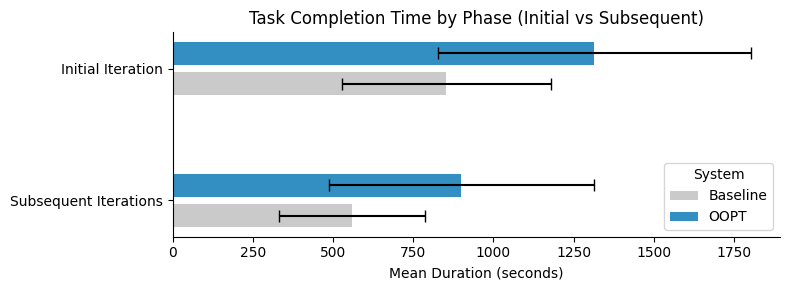


% ===== LaTeX table =====

\begin{table}[t]
\centering
\small
\setlength{\tabcolsep}{6pt}
\begin{tabular}{lcccccc}
\toprule
& \multicolumn{2}{c}{Baseline} & \multicolumn{2}{c}{OOPT} & \multicolumn{2}{c}{Statistics} \\
Phase & mean & std & mean & std & p & Sig. \\
\midrule
Initial Iteration & 560.20 & 227.18 & 900.18 & 412.86 & 0.023 & * \\
Subsequent Iterations & 852.75 & 326.04 & 1314.78 & 488.40 & 0.013 & * \\
\bottomrule
\end{tabular}
\caption{Task Completion Time by Phase}
\label{tab:time_by_phase}
\end{table}


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

def _welch_from_summary(m1, s1, n1, m2, s2, n2):
    se = np.sqrt((s1**2)/n1 + (s2**2)/n2)
    if se == 0: return np.nan
    t = (m1 - m2) / se
    df = ( (s1**2/n1 + s2**2/n2)**2 /
           ((s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1)) )
    return 2 * stats.t.sf(abs(t), df)

def _stars(p):
    if pd.isna(p): return "-"
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return "n.s."

def plot_time_by_phase_with_table(initial_csv, other_csv, out_path=None):
    df_init = pd.read_csv(initial_csv)
    df_other = pd.read_csv(other_csv)

    # ───────────── Plot (기존 코드 유지) ─────────────
    phases = ["Initial Iteration", "Subsequent Iterations"]
    phases.reverse()
    y = np.arange(len(phases))
    height = 0.35
    systems = df_init["system_type"].tolist()
    color_map = {"system1": "#BDBDBD", "system2": "#0072B2"}
    label_map = {"system1": "Baseline", "system2": "OOPT"}
    bar_offsets = np.linspace(-height/3, height/3, len(systems))

    fig, ax = plt.subplots(figsize=(8, 3))
    legend_labels, legend_patches = [], []

    for i, sys in enumerate(systems):
        mean_init = df_init.loc[df_init["system_type"]==sys, "mean"].values[0]
        err_init  = df_init.loc[df_init["system_type"]==sys, "std"].values[0]
        mean_other= df_other.loc[df_other["system_type"]==sys, "mean"].values[0]
        err_other = df_other.loc[df_other["system_type"]==sys, "std"].values[0]

        color = color_map.get(sys, "#ccc")
        label = label_map.get(sys, sys)

        bar1 = ax.barh(y[0]+bar_offsets[i], mean_init, height/len(systems),
                       xerr=err_init, capsize=4, color=color, alpha=0.8, label=label)
        ax.barh(y[1]+bar_offsets[i], mean_other, height/len(systems),
                xerr=err_other, capsize=4, color=color, alpha=0.8)

        legend_labels.append(label)
        legend_patches.append(bar1)

    ax.set_yticks(y)
    ax.set_yticklabels(phases)
    ax.set_xlabel("Mean Duration (seconds)")
    ax.set_title("Task Completion Time by Phase (Initial vs Subsequent)")
    ax.legend(legend_patches, legend_labels, title="System")
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=150)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    plt.savefig("figure_0903/task_completion_time_by_phase.pdf")
    # Remove 테두리
    plt.show()

    # ───────────── LaTeX 테이블 생성 ─────────────
    rows = []
    for phase, df_phase in zip(["Initial Iteration", "Subsequent Iterations"], [df_init, df_other]):
        # Baseline (system1)
        m_b = df_phase.loc[df_phase["system_type"]=="system1", "mean"].values[0]
        s_b = df_phase.loc[df_phase["system_type"]=="system1", "std"].values[0]
        n_b = 12 #df_phase.loc[df_phase["system_type"]=="system1", 12].values[0]
        # OOPT (system2)
        m_o = df_phase.loc[df_phase["system_type"]=="system2", "mean"].values[0]
        s_o = df_phase.loc[df_phase["system_type"]=="system2", "std"].values[0]
        n_o = 12# df_phase.loc[df_phase["system_type"]=="system2", 12].values[0]

        pval = _welch_from_summary(m_b, s_b, n_b, m_o, s_o, n_o)
        rows.append((phase, f"{m_b:.2f}", f"{s_b:.2f}",
                              f"{m_o:.2f}", f"{s_o:.2f}",
                              f"{pval:.3f}", _stars(pval)))

    # LaTeX 출력 (위에 주신 스타일 기반)
    latex_lines = []
    latex_lines.append("\\begin{table}[t]")
    latex_lines.append("\\centering")
    latex_lines.append("\\small")
    latex_lines.append("\\setlength{\\tabcolsep}{6pt}")
    latex_lines.append("\\begin{tabular}{lcccccc}")
    latex_lines.append("\\toprule")
    latex_lines.append("& \\multicolumn{2}{c}{Baseline} & \\multicolumn{2}{c}{OOPT} & \\multicolumn{2}{c}{Statistics} \\\\")
    latex_lines.append("Phase & mean & std & mean & std & p & Sig. \\\\")
    latex_lines.append("\\midrule")
    for r in rows:
        latex_lines.append(f"{r[0]} & {r[1]} & {r[2]} & {r[3]} & {r[4]} & {r[5]} & {r[6]} \\\\")
    latex_lines.append("\\bottomrule")
    latex_lines.append("\\end{tabular}")
    latex_lines.append("\\caption{Task Completion Time by Phase}")
    latex_lines.append("\\label{tab:time_by_phase}")
    latex_lines.append("\\end{table}")

    latex_code = "\n".join(latex_lines)
    print("\n% ===== LaTeX table =====\n")
    print(latex_code)
    return latex_code

# 사용 예시
latex_code = plot_time_by_phase_with_table(
    "result/time/system_duration_stats_initial.csv",
    "result/time/system_duration_stats_other.csv"
)


Figure saved to: figure_0903/combined_analysis.svg


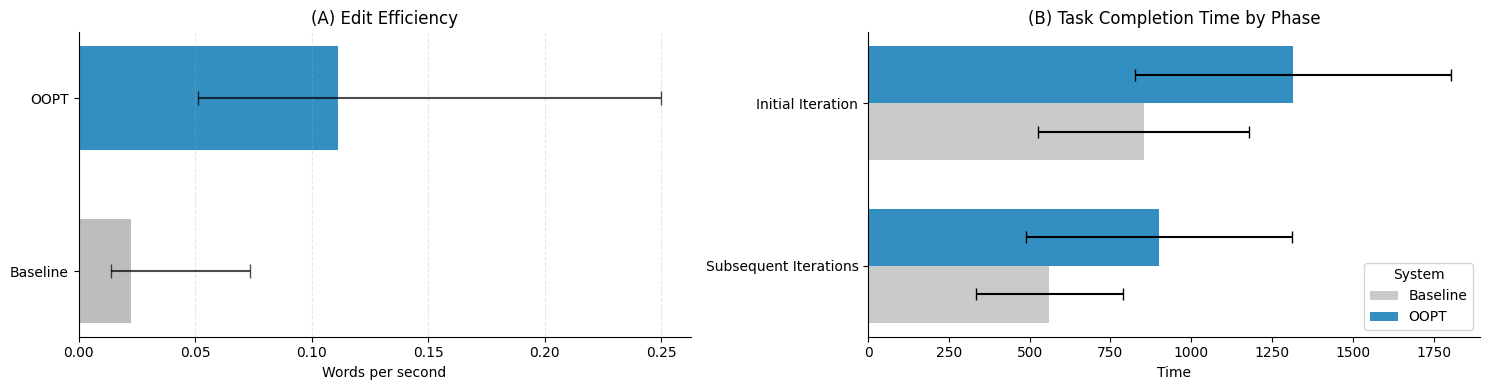


=== Words per Second Statistics ===


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from matplotlib.lines import Line2D

# -------------------------
# 공통 설정 및 색상 팔레트
# -------------------------
COLOR = {"Baseline": "#BDBDBD", "OOPT": "#0072B2"}
LABEL_MAP = {"system1": "Baseline", "system2": "OOPT"}

# -------------------------
# 유틸리티 함수들
# -------------------------
def _welch_from_summary(m1, s1, n1, m2, s2, n2):
    se = np.sqrt((s1**2)/n1 + (s2**2)/n2)
    if se == 0: return np.nan
    t = (m1 - m2) / se
    df = ( (s1**2/n1 + s2**2/n2)**2 /
           ((s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1)) )
    return 2 * stats.t.sf(abs(t), df)

def _stars(p):
    if pd.isna(p): return "-"
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return "n.s."

def create_words_per_sec_chart(ax, final_df):
    """Words per second 차트 생성 (가로 방향) - 원래 계산 방식 유지"""
    # Data preprocessing - 원래 코드와 동일하게
    final_df = final_df.copy()
    final_df['words_per_sec'] = 1 / final_df['sec_per_word']
    
    # Remove rows where sec_per_word was 0 (which would make words_per_sec infinite)
    # Also remove any infinite or NaN values
    final_df = final_df[np.isfinite(final_df['words_per_sec']) & (final_df['words_per_sec'] > 0)]
    
    systems = final_df['system'].unique()
    medians = []
    q1s = []
    q3s = []
    colors = []
    
    for system in systems:
        data = final_df[final_df['system'] == system]['words_per_sec'].dropna()
        if len(data) > 0:
            medians.append(data.median())
            q1s.append(data.quantile(0.25))
            q3s.append(data.quantile(0.75))
            colors.append(COLOR.get(system, "#666666"))
        else:
            medians.append(0)
            q1s.append(0)
            q3s.append(0)
            colors.append(COLOR.get(system, "#666666"))
    
    y_pos = np.arange(len(systems))
    
    # IQR을 에러바로 사용
    xerr_low = [med - q1 for med, q1 in zip(medians, q1s)]
    xerr_high = [q3 - med for med, q3 in zip(medians, q3s)]
    
    bars = ax.barh(y_pos, medians, height=0.6)
    
    # 바 스타일링
    for i, (bar, system) in enumerate(zip(bars, systems)):
        if system == "Baseline":
            bar.set_facecolor(COLOR["Baseline"])
            bar.set_linewidth(2)
        else:  # OOPT
            bar.set_facecolor(COLOR["OOPT"])
            bar.set_alpha(0.8)
    
    # IQR 에러바
    ax.errorbar(medians, y_pos, xerr=[xerr_low, xerr_high], 
                fmt='none', ecolor='black', capsize=5, 
                linewidth=1.5, alpha=0.7)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(systems)
    ax.set_xlabel("Words per second")
    ax.set_title("(A) Edit Efficiency")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    
    return ax

def create_time_by_phase_chart(ax, initial_csv, other_csv):
    """Task completion time by phase 차트 생성"""
    df_init = pd.read_csv(initial_csv)
    df_other = pd.read_csv(other_csv)
    
    phases = ["Initial Iteration", "Subsequent Iterations"]
    phases.reverse()
    y = np.array([0, 0.5])
    height = 0.35
    systems = df_init["system_type"].tolist()
    color_map = {"system1": "#BDBDBD", "system2": "#0072B2"}
    label_map = {"system1": "Baseline", "system2": "OOPT"}
    bar_offsets = np.linspace(-height/4, height/4, len(systems))
    
    legend_labels, legend_patches = [], []
    
    for i, sys in enumerate(systems):
        mean_init = df_init.loc[df_init["system_type"]==sys, "mean"].values[0]
        err_init  = df_init.loc[df_init["system_type"]==sys, "std"].values[0]
        mean_other= df_other.loc[df_other["system_type"]==sys, "mean"].values[0]
        err_other = df_other.loc[df_other["system_type"]==sys, "std"].values[0]
        
        color = color_map.get(sys, "#ccc")
        label = label_map.get(sys, sys)
        
        bar1 = ax.barh(y[0]+bar_offsets[i], mean_init, height/len(systems),
                       xerr=err_init, capsize=4, color=color, alpha=0.8, label=label)
        ax.barh(y[1]+bar_offsets[i], mean_other, height/len(systems),
                xerr=err_other, capsize=4, color=color, alpha=0.8)
        
        legend_labels.append(label)
        legend_patches.append(bar1)
    
    ax.set_yticks(y)
    ax.set_yticklabels(phases)
    ax.set_xlabel("Time")
    ax.set_title("(B) Task Completion Time by Phase")
    ax.legend(legend_patches, legend_labels, title="System", loc='lower right')
    
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    
    return ax

# -------------------------
# 메인 함수: 두 차트를 하나의 figure로 결합
# -------------------------
def create_combined_figure(final_df, initial_csv, other_csv, figsize=(12, 5), save_path=None):
    """두 차트를 하나의 figure로 결합"""
    
    # 1x2 subplot 생성
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # 좌측: Words per second 차트
    create_words_per_sec_chart(ax1, final_df)
    
    # 우측: Task completion time 차트
    create_time_by_phase_chart(ax2, initial_csv, other_csv)
    
    # 전체 제목 추가 (선택사항)
    # fig.suptitle("System Comparison: Edit Efficiency and Task Completion Time", 
    #              fontsize=14, y=0.98)
    
    # 레이아웃 조정
    plt.tight_layout()
    
    # 저장
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to: {save_path}")
    
    plt.show()
    return fig, (ax1, ax2)

# -------------------------
# 사용 예시
# -------------------------
if __name__ == "__main__":
    # 데이터 로드 (실제 데이터로 교체하세요)
    # final_df는 'system', 'sec_per_word' 컬럼을 가져야 합니다
    # 예시 데이터 생성
    np.random.seed(42)
    n_baseline = 50
    n_oopt = 50
    
    # final_example = pd.DataFrame({
    #     'system': ['Baseline'] * n_baseline + ['OOPT'] * n_oopt,
    #     'sec_per_word': np.concatenate([
    #         np.random.gamma(2, 0.5, n_baseline),  # Baseline: 더 느림
    #         np.random.gamma(1.5, 0.3, n_oopt)     # OOPT: 더 빠름
    #     ])
    # })
    
    # CSV 파일 경로들
    initial_csv = "result/time/system_duration_stats_initial.csv"
    other_csv = "result/time/system_duration_stats_other.csv"
    
    # 결합된 figure 생성
    fig, axes = create_combined_figure(
        final_df=final,
        initial_csv=initial_csv,
        other_csv=other_csv,
        figsize=(15, 4),  # 세로 레이아웃에 맞게 조정
        save_path="figure_0903/combined_analysis.svg"
    )
    
    # 통계 정보 출력
    print("\n=== Words per Second Statistics ===")